<a href="https://colab.research.google.com/github/tost1n/Tp-laboratorio/blob/main/Tp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# **Carga del dataset**







El dataset proviene del Ministerio de Trabajo de Argentina y
contiene información sobre empleo registrado en el AMBA
desagregada por departamento, sector económico y género.
Se carga directamente desde el repositorio del grupo en GitHub.

In [ ]:
url="https://raw.githubusercontent.com/tost1n/Tp-laboratorio/refs/heads/main/Datasets%20de%20limpieza/Empleo-AMBA.csv"

DF=pd.read_csv(url)


/tmp/ipykernel_6309/3637845576.py:3: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  DF=pd.read_csv(url)


#correccion de primeras filas

Mostramos las primeras filas del dataset para verificar que
se cargó correctamente y conocer la estructura de las columnas

In [ ]:
DF.head()


,LINK,provincia_id,departamento_id,clae2,letra,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Poblacion_radio,Viviendas_radio
0,1_10_12,2,2007,1.0,A,2,2.0,NaN,150000.0000,150000.000,NaN,150000.00,150000.000,NaN,584,606
1,1_10_12,2,2007,6.0,B,1,1.0,NaN,337377.8100,337377.810,NaN,337377.81,337377.810,NaN,584,606
2,1_10_12,2,2007,10.0,C,4,2.0,2.0,53289.2875,43690.815,62887.76,48271.49,43690.815,62887.76,584,606
3,1_10_12,2,2007,13.0,C,1,NaN,1.0,72176.2000,NaN,72176.20,72176.20,NaN,72176.20,584,606
4,1_10_12,2,2007,21.0,C,1,1.0,NaN,373915.9500,373915.950,NaN,373915.95,373915.950,NaN,584,606


# últimas filas del dataset

Mostramos las últimas filas del dataset con .tail() para verificar
que los datos se cargaron correctamente hasta el final del archivo
y que no haya valores extraños o erroneos al final del dataset.

In [ ]:
DF.tail()

,LINK,provincia_id,departamento_id,clae2,letra,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Poblacion_radio,Viviendas_radio
508984,68613310,6,6861,84.0,O,16,6.0,10.0,209554.436875,454433.251667,62627.148000,69575.290,186903.265,51658.81,1022,392
508985,68613310,6,6861,85.0,P,20,5.0,15.0,140988.221500,142675.562000,140425.774667,117515.380,127509.610,107521.15,1022,392
508986,68613310,6,6861,86.0,Q,7,2.0,5.0,165429.368571,103643.960000,190143.532000,104359.000,103643.960,104359.00,1022,392
508987,68613310,6,6861,91.0,R,1,NaN,1.0,137147.570000,NaN,137147.570000,137147.570,NaN,137147.57,1022,392
508988,68613310,6,6861,94.0,S,4,3.0,1.0,114986.142500,97687.203333,166882.960000,127855.085,125019.960,166882.96,1022,392


**Tipos de datos del dataset**

Revisamos los tipos de datos de cada columna para verificar
que las variables numéricas estén correctamente reconocidas
como números y las categóricas como texto. Esto es importante
antes de hacer cualquier cálculo o transformación.

In [ ]:
DF.dtypes

,0
LINK,object
provincia_id,int64
departamento_id,int64
clae2,float64
letra,object
Cantidad_trabajadores,int64
Cantidad_trabajadores_Hombres,float64
Cantidad_trabajadores_Mujeres,float64
Remuneracion_media,float64
Remuneracion_media_Hombres,float64


## describe()     del dataset

Calculamos las estadísticas descriptivas del dataset completo
para entender la distribución de cada variable numérica.
Esto nos permite identificar valores extremos, rangos y
promedios antes de comenzar el análisis, y detectar posibles
anomalías en los datos.

In [ ]:
DF.describe()

,provincia_id,departamento_id,clae2,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Poblacion_radio,Viviendas_radio
count,508989.000000,508989.000000,508921.000000,508989.000000,421001.000000,273953.000000,5.089890e+05,4.210010e+05,2.739530e+05,5.089890e+05,4.210010e+05,2.739530e+05,508989.000000,508989.000000
mean,4.769482,5114.854800,52.100965,4.437935,3.032862,3.577201,1.334810e+05,1.431750e+05,1.176492e+05,1.254887e+05,1.363061e+05,1.129792e+05,1029.983839,357.028519
std,1.846051,2045.946851,26.030957,7.793089,3.987388,5.915825,3.571972e+05,4.749185e+05,1.704005e+05,3.445662e+05,4.662013e+05,1.659409e+05,419.087095,123.433025
min,2.000000,2007.000000,1.000000,1.000000,1.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,53.000000,12.000000
25%,2.000000,2091.000000,28.000000,1.000000,1.000000,1.000000,6.891100e+04,7.040095e+04,6.245392e+04,6.669544e+04,6.874188e+04,6.037511e+04,754.000000,278.000000
50%,6.000000,6410.000000,52.000000,2.000000,2.000000,1.000000,9.929042e+04,1.026374e+05,9.143507e+04,9.379298e+04,9.843326e+04,8.786776e+04,946.000000,341.000000
75%,6.000000,6539.000000,74.000000,4.000000,3.000000,3.000000,1.493358e+05,1.578475e+05,1.356229e+05,1.406099e+05,1.501897e+05,1.297743e+05,1225.000000,415.000000
max,6.000000,6861.000000,99.000000,254.000000,186.000000,134.000000,1.029963e+08,1.405377e+08,2.776678e+07,1.029963e+08,1.405377e+08,2.776678e+07,5895.000000,1405.000000


##***Pregunta de investigación***

**¿Cuál es la pregunta?**
¿Los departamentos del AMBA con una estructura económica más diversa
presentan salarios más altos y menor brecha salarial de género que
aquellos especializados en pocas actividades?

**¿Por qué vale la pena responderla?**
La composición sectorial de un territorio puede influir directamente
sobre las condiciones laborales de su población. Entender si la
diversificación económica se asocia con mejores salarios e igualdad
de género permite iluminar desigualdades territoriales dentro del AMBA.

**¿Qué encontramos?**
Con base en los análisis que hemos realizado, aquí les presentamos una respuesta completa a su pregunta sobre si los departamentos de AMBA con estructuras económicas más diversificadas presentan salarios más altos, menor desigualdad salarial de género y diferentes patrones de empleo:

***Salarios más altos:***

Encontramos una correlación positiva moderada de 0.48 entre la «Cantidad de Rubros» (número de sectores) y la «Remuneración Media ($)» (remuneración promedio) por departamento. Esto sugiere que los departamentos con mayor diversidad de actividades económicas tienden a tener salarios promedio más altos.

***Menor desigualdad salarial de género***:

Nuestro análisis mostró una correlación negativa moderada de -0.55 entre la «Cantidad de Rubros» y la «Brecha Salarial Promedio». Este es un hallazgo significativo, que indica que una mayor diversidad de sectores económicos se asocia con una menor brecha salarial de género.
Además, observamos una correlación negativa moderada de -0,46 entre el número total de trabajadores y la brecha salarial promedio, lo que sugiere que los departamentos con mayor número de trabajadores tienden a presentar una menor brecha salarial.

***Patrones de empleo diferentes***:

Si bien no hemos visualizado explícitamente los patrones de empleo en términos de concentraciones o cambios sectoriales específicos, el hecho de que una mayor cantidad de rubros se traduzca en salarios más altos y una menor brecha salarial implica entornos laborales más estables e inclusivos. Es probable que los departamentos con sectores más diversos ofrezcan una gama más amplia de oportunidades laborales, lo que podría generar una mejor correspondencia entre las habilidades y los puestos disponibles, y fomentar un mercado laboral más competitivo que beneficie a los empleados, incluidas las mujeres.



***Limitaciones y Observaciones***

***Correlación no implica causalidad***:

El análisis identifica asociaciones estadísticas entre diversificación económica, salarios y brecha salarial, pero no permite establecer relaciones causales.

***Medición de la diversificación***

La diversificación económica fue aproximada mediante la cantidad de rubros presentes en cada departamento, lo que constituye una medida simplificada que no refleja la intensidad o importancia relativa de cada actividad económica.

***Nivel de agregación***

El estudio se realizó a nivel departamental, por lo que pueden existir diferencias internas dentro de cada departamento que no son capturadas por los datos utilizados.


***Variables omitidas***
Factores como experiencia laboral, edad, composición sectorial específica o características empresariales podrían influir en los resultados observados y no fueron considerados en este trabajo.

## Valores nulos del dataset

Analizamos la cantidad de valores nulos por columna para
entender la calidad de los datos.

In [ ]:
#Consultamos si tiene datos faltantes
DF.isnull().sum()

,0
LINK,0
provincia_id,0
departamento_id,0
clae2,68
letra,68
Cantidad_trabajadores,0
Cantidad_trabajadores_Hombres,87988
Cantidad_trabajadores_Mujeres,235036
Remuneracion_media,0
Remuneracion_media_Hombres,87988


In [ ]:
#Borramos los datos nulos que interpretamos como faltantes
print(f"Forma del dataframe antes de borrar las filas con nulos: {DF.shape}")

# Borrar filas si "clae2" o "letra" son nulos
DF_limpio = DF.dropna(subset=["clae2", "letra"])

print(f"Forma del dataframe despues de borrar las filas con nulos: {DF_limpio.shape}")
DF_limpio

Forma del dataframe antes de borrar las filas con nulos: (508989, 16)
Forma del dataframe despues de borrar las filas con nulos: (508921, 16)


,LINK,provincia_id,departamento_id,clae2,letra,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Poblacion_radio,Viviendas_radio
0,1_10_12,2,2007,1.0,A,2,2.0,NaN,150000.000000,150000.000000,NaN,150000.000,150000.000,NaN,584,606
1,1_10_12,2,2007,6.0,B,1,1.0,NaN,337377.810000,337377.810000,NaN,337377.810,337377.810,NaN,584,606
2,1_10_12,2,2007,10.0,C,4,2.0,2.0,53289.287500,43690.815000,62887.760000,48271.490,43690.815,62887.76,584,606
3,1_10_12,2,2007,13.0,C,1,NaN,1.0,72176.200000,NaN,72176.200000,72176.200,NaN,72176.20,584,606
4,1_10_12,2,2007,21.0,C,1,1.0,NaN,373915.950000,373915.950000,NaN,373915.950,373915.950,NaN,584,606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508984,68613310,6,6861,84.0,O,16,6.0,10.0,209554.436875,454433.251667,62627.148000,69575.290,186903.265,51658.81,1022,392
508985,68613310,6,6861,85.0,P,20,5.0,15.0,140988.221500,142675.562000,140425.774667,117515.380,127509.610,107521.15,1022,392
508986,68613310,6,6861,86.0,Q,7,2.0,5.0,165429.368571,103643.960000,190143.532000,104359.000,103643.960,104359.00,1022,392
508987,68613310,6,6861,91.0,R,1,NaN,1.0,137147.570000,NaN,137147.570000,137147.570,NaN,137147.57,1022,392


## Tratamiento de valores nulos

Los valores nulos en las columnas de cantidad de trabajadores
y remuneraciones por género se interpretan como cero, ya que
representan sectores donde no hay trabajadores registrados
de ese género. Se reemplazan por 0 para poder operar con
ellos como números en los cálculos posteriores.

In [ ]:
#Interpretamos los datos nulos en ciertas columnas como valor 0 y lo cambiamos para poder analizarlos como un numero
columnas_con_nulos = ["Cantidad_trabajadores_Hombres", "Cantidad_trabajadores_Mujeres", "Remuneracion_media_Hombres", "Remuneracion_media_Mujeres", "Remuneracion_mediana_Hombres", "Remuneracion_mediana_Mujeres"]
DF_limpio[columnas_con_nulos] = DF_limpio[columnas_con_nulos].fillna(0)
DF_limpio

/tmp/ipykernel_6309/3520448293.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_limpio[columnas_con_nulos] = DF_limpio[columnas_con_nulos].fillna(0)


,LINK,provincia_id,departamento_id,clae2,letra,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Poblacion_radio,Viviendas_radio
0,1_10_12,2,2007,1.0,A,2,2.0,0.0,150000.000000,150000.000000,0.000000,150000.000,150000.000,0.00,584,606
1,1_10_12,2,2007,6.0,B,1,1.0,0.0,337377.810000,337377.810000,0.000000,337377.810,337377.810,0.00,584,606
2,1_10_12,2,2007,10.0,C,4,2.0,2.0,53289.287500,43690.815000,62887.760000,48271.490,43690.815,62887.76,584,606
3,1_10_12,2,2007,13.0,C,1,0.0,1.0,72176.200000,0.000000,72176.200000,72176.200,0.000,72176.20,584,606
4,1_10_12,2,2007,21.0,C,1,1.0,0.0,373915.950000,373915.950000,0.000000,373915.950,373915.950,0.00,584,606
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508984,68613310,6,6861,84.0,O,16,6.0,10.0,209554.436875,454433.251667,62627.148000,69575.290,186903.265,51658.81,1022,392
508985,68613310,6,6861,85.0,P,20,5.0,15.0,140988.221500,142675.562000,140425.774667,117515.380,127509.610,107521.15,1022,392
508986,68613310,6,6861,86.0,Q,7,2.0,5.0,165429.368571,103643.960000,190143.532000,104359.000,103643.960,104359.00,1022,392
508987,68613310,6,6861,91.0,R,1,0.0,1.0,137147.570000,0.000000,137147.570000,137147.570,0.000,137147.57,1022,392


In [ ]:
# Verificamos los cambios
DF_limpio.isnull().sum()

,0
LINK,0
provincia_id,0
departamento_id,0
clae2,0
letra,0
Cantidad_trabajadores,0
Cantidad_trabajadores_Hombres,0
Cantidad_trabajadores_Mujeres,0
Remuneracion_media,0
Remuneracion_media_Hombres,0


In [ ]:
# Contamos el número de filas duplicadas
duplicadas = DF_limpio.duplicated().sum()
print(f"Número de filas duplicadas: {duplicadas}")

Número de filas duplicadas: 0


## Creación de columnas derivadas


Esta columna es un indicador de desigualdad económica relativa. En lugar de mirar los salarios de hombres y mujeres por separado, esta variable unifica ambos datos en un solo número que mide qué porcentaje menos (o más) ganan las mujeres en comparación con los hombres en un mismo radio censal o departamento del AMBA.

En economía laboral y urbana, es fundamental usar este tipo de indicadores relativos porque permiten comparar zonas muy distintas entre sí. No es lo mismo una diferencia absoluta de $50.000 en un barrio de ingresos bajos que en un barrio de ingresos muy altos; al transformarlo en un porcentaje (un ratio relativo), la comparación se vuelve justa y metodológicamente sólida.

Además, el dataset utiliza la remuneración mediana (en lugar del promedio), lo cual es un gran acierto metodológico del grupo, ya que la mediana no se ve afectada por salarios extremadamente altos o bajos, reflejando mejor la realidad del "trabajador típico" de cada zona.
$$\text{Brecha Salarial} = \frac{\text{Salario Hombres} - \text{Salario Mujeres}}{\text{Salario Hombres}}$$

Si el resultado es 0.20: Significa que la brecha es del 20% en favor de los hombres. Dicho de otra forma, por cada $100 que gana un hombre en ese radio del AMBA, una mujer gana $80.

Si el resultado es 0.00: Significa paridad absoluta (0% de brecha). Ambos géneros tienen exactamente la misma remuneración mediana en esa zona.

Si el resultado es -0.05: Significa una brecha del 5% en favor de las mujeres. En ese punto específico, la remuneración mediana femenina supera a la masculina.

In [ ]:
# 1. Creamos la columna derivada utilizando DF_limpio
DF_limpio['Brecha_Salarial_Genero'] = (DF_limpio['Remuneracion_mediana_Hombres'] - DF_limpio['Remuneracion_mediana_Mujeres']) / DF_limpio['Remuneracion_mediana_Hombres']

# Reemplazar valores infinitos resultantes de la división por cero con NaN
DF_limpio['Brecha_Salarial_Genero'] = DF_limpio['Brecha_Salarial_Genero'].replace([np.inf, -np.inf], np.nan)

# 2. Verificación de los resultados en pantalla
print("¡Columna de Brecha Salarial creada con éxito!")
display(DF_limpio[['Remuneracion_mediana_Hombres', 'Remuneracion_mediana_Mujeres', 'Brecha_Salarial_Genero']].head())

¡Columna de Brecha Salarial creada con éxito!


/tmp/ipykernel_6309/424674540.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_limpio['Brecha_Salarial_Genero'] = (DF_limpio['Remuneracion_mediana_Hombres'] - DF_limpio['Remuneracion_mediana_Mujeres']) / DF_limpio['Remuneracion_mediana_Hombres']
/tmp/ipykernel_6309/424674540.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_limpio['Brecha_Salarial_Genero'] = DF_limpio['Brecha_Salarial_Genero'].replace([np.inf, -np.inf], np.nan)


,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Brecha_Salarial_Genero
0,150000.000,0.00,1.000000
1,337377.810,0.00,1.000000
2,43690.815,62887.76,-0.439382
3,0.000,72176.20,NaN
4,373915.950,0.00,1.000000


## Creación de columnas derivadas


Esta variable transforma un dato numérico continuo y "pesado" (la cantidad exacta de habitantes de un radio censal, Poblacion_radio) en una variable categórica u ordinal (Baja, Media y Alta Densidad).

Se utilizó un modelo de lenguaje para adaptar las fórmulas de preprocesamiento de datos a la estructura del DataFrame DF_limpio. Se crearon dos transformaciones: (1) La variable derivada 'Brecha_Salarial_Genero' para analizar las desigualdades relativas, y (2) La categorización 'Categoria_Densidad' mediante cuantiles para segmentar el comportamiento de los patrones de empleo

In [ ]:
# 1. Agrupamos la variable continua en 3 categorías simétricas usando DF_limpio
DF_limpio['Categoria_Densidad'] = pd.qcut(DF_limpio['Poblacion_radio'], q=3, labels=['Baja Densidad', 'Media Densidad', 'Alta Densidad'])

# 2. Verificación de cuántos radios censales cayeron en cada grupo
print("¡Segmentación por densidad completada!")
print(DF_limpio['Categoria_Densidad'].value_counts())

¡Segmentación por densidad completada!
Categoria_Densidad
Media Densidad    169741
Baja Densidad     169669
Alta Densidad     169511
Name: count, dtype: int64


/tmp/ipykernel_6309/2305072428.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_limpio['Categoria_Densidad'] = pd.qcut(DF_limpio['Poblacion_radio'], q=3, labels=['Baja Densidad', 'Media Densidad', 'Alta Densidad'])


## Mapeo de sectores económicos (CLAE)

Para facilitar la interpretación de los resultados, reemplazamos
los códigos de letra del clasificador CLAE por sus nombres
completos. Esto permite que los gráficos y tablas sean más
legibles para cualquier lector sin conocimiento previo
de la clasificación oficial.

In [ ]:
clae_mapping = {
    'A': 'Agricultura, ganadería, caza, silvicultura y pesca',
    'B': 'Explotación de minas y canteras',
    'C': 'Industrias manufactureras',
    'D': 'Suministro de electricidad, gas, vapor y aire acondicionado',
    'E': 'Suministro de agua; cloacas, gestión de residuos y descontaminación',
    'F': 'Construcción',
    'G': 'Comercio al por mayor y al por menor; reparación de vehículos automotores y motocicletas',
    'H': 'Transporte y almacenamiento',
    'I': 'Alojamiento y servicios de comida',
    'J': 'Información y comunicación',
    'K': 'Actividades financieras y de seguros',
    'L': 'Actividades inmobiliarias',
    'M': 'Actividades profesionales, científicas y técnicas',
    'N': 'Actividades administrativas y servicios de apoyo',
    'O': 'Administración pública, defensa y seguridad social obligatoria',
    'P': 'Enseñanza',
    'Q': 'Actividades de atención de la salud humana y servicios sociales',
    'R': 'Artes, entretenimiento y recreación',
    'S': 'Otras actividades de servicios',
    'T': 'Servicios de hogares privados como empleadores',
    'U': 'Servicios de organizaciones y organismos extraterritoriales'
}

DF_limpio['clae2_description'] = DF_limpio['letra'].map(clae_mapping)
display(DF_limpio['clae2_description'].value_counts().head(10))

/tmp/ipykernel_6309/391166073.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_limpio['clae2_description'] = DF_limpio['letra'].map(clae_mapping)


,count
clae2_description,
Industrias manufactureras,139031
Actividades administrativas y servicios de apoyo,44335
Comercio al por mayor y al por menor; reparación de vehículos automotores y motocicletas,36739
Transporte y almacenamiento,36724
Información y comunicación,33919
"Actividades profesionales, científicas y técnicas",33443
Construcción,27486
Actividades financieras y de seguros,24494
Otras actividades de servicios,20037


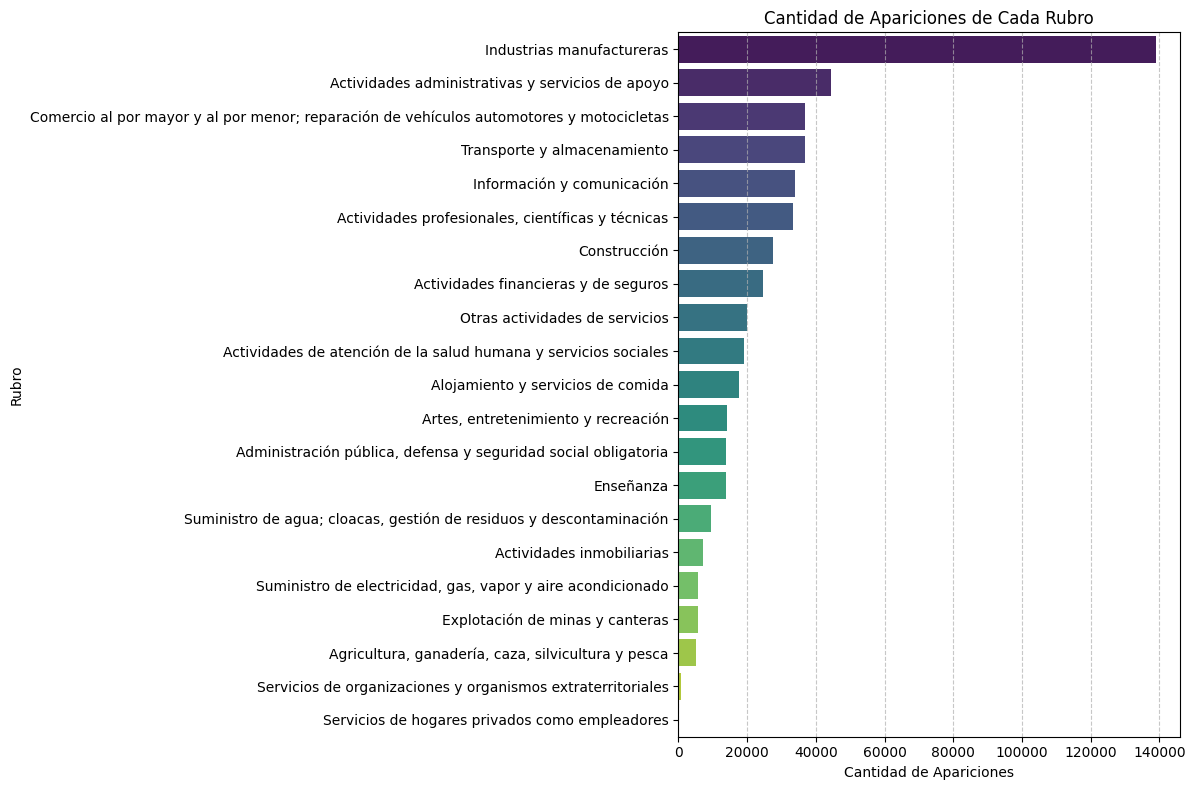

In [ ]:
# Cuento cuantas veces aparecen 'clae2_description'
rubros_cantidad = DF_limpio['clae2_description'].value_counts().reset_index()
rubros_cantidad.columns = ['Rubro', 'Cantidad de Apariciones']

rubros_cantidad_sorted = rubros_cantidad.sort_values(by='Cantidad de Apariciones', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Cantidad de Apariciones', y='Rubro', data=rubros_cantidad_sorted, hue='Rubro', palette='viridis', legend=False)
plt.title('Cantidad de Apariciones de Cada Rubro')
plt.xlabel('Cantidad de Apariciones')
plt.ylabel('Rubro')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Se puede ver que el rubro  "Industrias Manufactureras" es el mas ocurrente y los "Servicios de hogares privados como empleadores" es el menos ocurrente

## Incorporación de nombres de departamentos

Cargamos un archivo adicional con los nombres oficiales de
los departamentos del AMBA para reemplazar los códigos numéricos
de departamento_id por nombres legibles. Esto facilita la
interpretación de los gráficos y tablas del análisis.

In [ ]:
df_jurisdicciones = pd.read_csv('https://raw.githubusercontent.com/tost1n/Tp-laboratorio/refs/heads/main/jurisdicciones.csv')
display(df_jurisdicciones.head())

,provincia_id,provincia,departamento_id,departamento
0,2,CABA,2007,Comuna 1
1,2,CABA,2014,Comuna 2
2,2,CABA,2021,Comuna 3
3,2,CABA,2028,Comuna 4
4,2,CABA,2035,Comuna 5


In [ ]:
DF_limpio = pd.merge(DF_limpio, df_jurisdicciones[['provincia_id', 'provincia', 'departamento_id', 'departamento']],
                     on=['provincia_id', 'departamento_id'],
                     how='left', suffixes=('_DF_limpio', '_df_jurisdicciones'))
DF_limpio.head()

,LINK,provincia_id,departamento_id,clae2,letra,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,...,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Poblacion_radio,Viviendas_radio,Brecha_Salarial_Genero,Categoria_Densidad,clae2_description,provincia,departamento
0,1_10_12,2,2007,1.0,A,2,2.0,0.0,150000.0000,150000.000,...,150000.00,150000.000,0.00,584,606,1.000000,Baja Densidad,"Agricultura, ganadería, caza, silvicultura y p...",CABA,Comuna 1
1,1_10_12,2,2007,6.0,B,1,1.0,0.0,337377.8100,337377.810,...,337377.81,337377.810,0.00,584,606,1.000000,Baja Densidad,Explotación de minas y canteras,CABA,Comuna 1
2,1_10_12,2,2007,10.0,C,4,2.0,2.0,53289.2875,43690.815,...,48271.49,43690.815,62887.76,584,606,-0.439382,Baja Densidad,Industrias manufactureras,CABA,Comuna 1
3,1_10_12,2,2007,13.0,C,1,0.0,1.0,72176.2000,0.000,...,72176.20,0.000,72176.20,584,606,NaN,Baja Densidad,Industrias manufactureras,CABA,Comuna 1
4,1_10_12,2,2007,21.0,C,1,1.0,0.0,373915.9500,373915.950,...,373915.95,373915.950,0.00,584,606,1.000000,Baja Densidad,Industrias manufactureras,CABA,Comuna 1


## Selección de variables clave para el análisis

De todas las columnas disponibles en el dataset, seleccionamos
únicamente las variables relevantes para responder la pregunta
de investigación: identificador y nombre del departamento,
cantidad de trabajadores por género y remuneraciones medias
y medianas. Esto simplifica el DataFrame y facilita
los cálculos posteriores.

In [ ]:
DF_Clave= DF_limpio[[
    "departamento_id",
    "departamento",
    "Cantidad_trabajadores",
    "Cantidad_trabajadores_Hombres",
    "Cantidad_trabajadores_Mujeres",
    "Remuneracion_media",
    "Remuneracion_media_Hombres",
    "Remuneracion_media_Mujeres",
    "Remuneracion_mediana",
    "Remuneracion_mediana_Hombres",
    "Remuneracion_mediana_Mujeres",
    "Brecha_Salarial_Genero",
     "clae2",
    "clae2_description",

]]

In [ ]:
DF_Clave.head().round(2)

,departamento_id,departamento,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Brecha_Salarial_Genero,clae2,clae2_description
0,2007,Comuna 1,2,2.0,0.0,150000.00,150000.00,0.00,150000.00,150000.00,0.00,1.00,1.0,"Agricultura, ganadería, caza, silvicultura y p..."
1,2007,Comuna 1,1,1.0,0.0,337377.81,337377.81,0.00,337377.81,337377.81,0.00,1.00,6.0,Explotación de minas y canteras
2,2007,Comuna 1,4,2.0,2.0,53289.29,43690.82,62887.76,48271.49,43690.82,62887.76,-0.44,10.0,Industrias manufactureras
3,2007,Comuna 1,1,0.0,1.0,72176.20,0.00,72176.20,72176.20,0.00,72176.20,NaN,13.0,Industrias manufactureras
4,2007,Comuna 1,1,1.0,0.0,373915.95,373915.95,0.00,373915.95,373915.95,0.00,1.00,21.0,Industrias manufactureras


In [ ]:
DF_Con_brecha=DF_Con_brecha = DF_Clave[
    (DF_Clave['Cantidad_trabajadores_Hombres'] > 0) &
    (DF_Clave['Cantidad_trabajadores_Mujeres'] > 0)
]


se aplico el filtro ***>0*** en ambas columnas para averiguar con que columnas contabamos para realizar la brecha salarial. Porque hubo casos en los cuales no habia hombres o mujeres, y arrojaba como resultado ***-inf*** o ***1*** en la brecha salarial.

In [ ]:
DF_Con_brecha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186193 entries, 2 to 508920
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   departamento_id                186193 non-null  int64  
 1   departamento                   186193 non-null  object 
 2   Cantidad_trabajadores          186193 non-null  int64  
 3   Cantidad_trabajadores_Hombres  186193 non-null  float64
 4   Cantidad_trabajadores_Mujeres  186193 non-null  float64
 5   Remuneracion_media             186193 non-null  float64
 6   Remuneracion_media_Hombres     186193 non-null  float64
 7   Remuneracion_media_Mujeres     186193 non-null  float64
 8   Remuneracion_mediana           186193 non-null  float64
 9   Remuneracion_mediana_Hombres   186193 non-null  float64
 10  Remuneracion_mediana_Mujeres   186193 non-null  float64
 11  Brecha_Salarial_Genero         185713 non-null  float64
 12  clae2                          1861

Las observaciones con las cuales se puede realizar la brecha salarial son 186193 de 508.921 registros, aproximadamene el 36,6% de los registros presentaba trabajadores de ambos géneros

In [ ]:
DF_Con_brecha.head(1000000).round(2)

,departamento_id,departamento,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Brecha_Salarial_Genero,clae2,clae2_description
2,2007,Comuna 1,4,2.0,2.0,53289.29,43690.82,62887.76,48271.49,43690.82,62887.76,-0.44,10.0,Industrias manufactureras
13,2007,Comuna 1,4,2.0,2.0,190019.08,273264.70,106773.45,165963.88,273264.70,106773.45,0.61,42.0,Construcción
16,2007,Comuna 1,17,11.0,6.0,61061.61,72858.31,39434.33,58596.49,77724.22,37287.56,0.52,47.0,Comercio al por mayor y al por menor; reparaci...
17,2007,Comuna 1,4,3.0,1.0,91028.99,90027.39,94033.78,112981.86,131929.95,94033.78,0.29,49.0,Transporte y almacenamiento
19,2007,Comuna 1,5,4.0,1.0,228995.35,262164.69,96318.00,96318.00,90092.96,96318.00,-0.07,52.0,Transporte y almacenamiento
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
508915,6861,Vicente López,3,1.0,2.0,48818.08,50974.76,47739.74,49349.95,50974.76,47739.74,0.06,82.0,Actividades administrativas y servicios de apoyo
508916,6861,Vicente López,16,6.0,10.0,209554.44,454433.25,62627.15,69575.29,186903.26,51658.81,0.72,84.0,"Administración pública, defensa y seguridad so..."
508917,6861,Vicente López,20,5.0,15.0,140988.22,142675.56,140425.77,117515.38,127509.61,107521.15,0.16,85.0,Enseñanza
508918,6861,Vicente López,7,2.0,5.0,165429.37,103643.96,190143.53,104359.00,103643.96,104359.00,-0.01,86.0,Actividades de atención de la salud humana y s...


Verificamos la cantidad de registros y el tipo de datos
del conjunto de datos donde no es posible calcular la
brecha salarial

In [ ]:
DF_sin_brecha = DF_Clave[
    (DF_Clave['Cantidad_trabajadores_Hombres'] == 0) |
    (DF_Clave['Cantidad_trabajadores_Mujeres'] == 0)
]

In [ ]:
#Tabla para los datos que no se le pueden realizar la brecha salarial
DF_sin_brecha.head()

,departamento_id,departamento,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Brecha_Salarial_Genero,clae2,clae2_description
0,2007,Comuna 1,2,2.0,0.0,150000.00,150000.00,0.0,150000.00,150000.00,0.0,1.0,1.0,"Agricultura, ganadería, caza, silvicultura y p..."
1,2007,Comuna 1,1,1.0,0.0,337377.81,337377.81,0.0,337377.81,337377.81,0.0,1.0,6.0,Explotación de minas y canteras
3,2007,Comuna 1,1,0.0,1.0,72176.20,0.00,72176.2,72176.20,0.00,72176.2,NaN,13.0,Industrias manufactureras
4,2007,Comuna 1,1,1.0,0.0,373915.95,373915.95,0.0,373915.95,373915.95,0.0,1.0,21.0,Industrias manufactureras
5,2007,Comuna 1,1,1.0,0.0,71575.93,71575.93,0.0,71575.93,71575.93,0.0,1.0,24.0,Industrias manufactureras


## Información del DataFrame sin brecha salarial

Verificamos la cantidad de registros y el tipo de datos
del conjunto de datos donde no es posible calcular la
brecha salarial, para entender qué proporción del dataset
queda excluida del análisis de género.

In [ ]:
DF_sin_brecha.info()

<class 'pandas.core.frame.DataFrame'>
Index: 322728 entries, 0 to 508919
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   departamento_id                322728 non-null  int64  
 1   departamento                   322728 non-null  object 
 2   Cantidad_trabajadores          322728 non-null  int64  
 3   Cantidad_trabajadores_Hombres  322728 non-null  float64
 4   Cantidad_trabajadores_Mujeres  322728 non-null  float64
 5   Remuneracion_media             322728 non-null  float64
 6   Remuneracion_media_Hombres     322728 non-null  float64
 7   Remuneracion_media_Mujeres     322728 non-null  float64
 8   Remuneracion_mediana           322728 non-null  float64
 9   Remuneracion_mediana_Hombres   322728 non-null  float64
 10  Remuneracion_mediana_Mujeres   322728 non-null  float64
 11  Brecha_Salarial_Genero         233448 non-null  float64
 12  clae2                          3227

### Cantidad de rubros económicos por departamento

Calculamos cuántos sectores económicos distintos tiene cada
departamento del AMBA. Esta variable es clave para medir la
diversidad económica: un departamento con muchos rubros distintos
tiene una estructura más diversificada que uno concentrado
en pocos sectores. Se utiliza .nunique() para contar los
sectores únicos por departamento.


In [ ]:
groupby_rubros = (
    DF_Clave.groupby(['departamento_id', 'departamento'])['clae2_description']
    .nunique()
    .sort_values(ascending=False)
    .reset_index()
)

groupby_rubros.columns = ['Departamento ID', 'Departamento', 'Cantidad de Rubros']

print("=== Departamentos ordenados por cantidad de rubros ===")
display(groupby_rubros.head(10).style
    .background_gradient(subset=['Cantidad de Rubros'], cmap='Blues')
    .set_properties(**{'text-align': 'center'})
)

=== Departamentos ordenados por cantidad de rubros ===


,Departamento ID,Departamento,Cantidad de Rubros
0,2007,Comuna 1,21
1,2021,Comuna 3,21
2,2042,Comuna 6,21
3,6028,Almirante Brown,21
4,2077,Comuna 11,21
5,2070,Comuna 10,21
6,2063,Comuna 9,21
7,2105,Comuna 15,21
8,2098,Comuna 14,21
9,2091,Comuna 13,21


In [ ]:
print("=== TOP 10 — Departamentos con menor cantidad de rubros ===")
display(groupby_rubros.tail(10).style
    .background_gradient(subset=['Cantidad de Rubros'], cmap='Blues_r')
    .set_properties(**{'text-align': 'center'})
)

=== TOP 10 — Departamentos con menor cantidad de rubros ===


,Departamento ID,Departamento,Cantidad de Rubros
41,6638,Pilar,20
42,6648,Presidente Perón,20
43,6840,Tres de Febrero,20
44,6805,Tigre,20
45,6756,San Isidro,20
46,6760,San Miguel,20
47,6861,Vicente López,20
48,6098,Berisso,19
49,6119,Brandsen,19
50,6329,General Las Heras,19


### Análisis del Heatmap de Brecha Salarial

Este mapa de calor visualiza la brecha salarial de género, calculada como `(Remuneración Mediana Hombres - Remuneración Mediana Mujeres) / Remuneración Mediana Hombres`, para cada combinación de departamento y actividad económica. Los valores han sido recortados a un rango entre -1 y 1 para mejorar la interpretabilidad visual y evitar que valores extremadamente altos o bajos distorsionen la escala de colores. En este rango:

*   **Valores cercanos a 0 (colores neutros/blanco)**: Indican paridad salarial o una brecha muy pequeña entre hombres y mujeres.
*   **Valores positivos (colores cálidos, ej. rojo)**: Sugieren una brecha salarial a favor de los hombres. Un valor de 0.5, por ejemplo, significa que los hombres ganan un 50% más que las mujeres.
*   **Valores negativos (colores fríos, ej. azul)**: Indican una brecha salarial a favor de las mujeres. Un valor de -0.5 significa que las mujeres ganan un 50% más que los hombres.

Este recorte ayuda a enfocarse en las diferencias salariales más comunes y a identificar patrones generales en la distribución de la brecha salarial de género, haciendo el mapa de calor más legible.

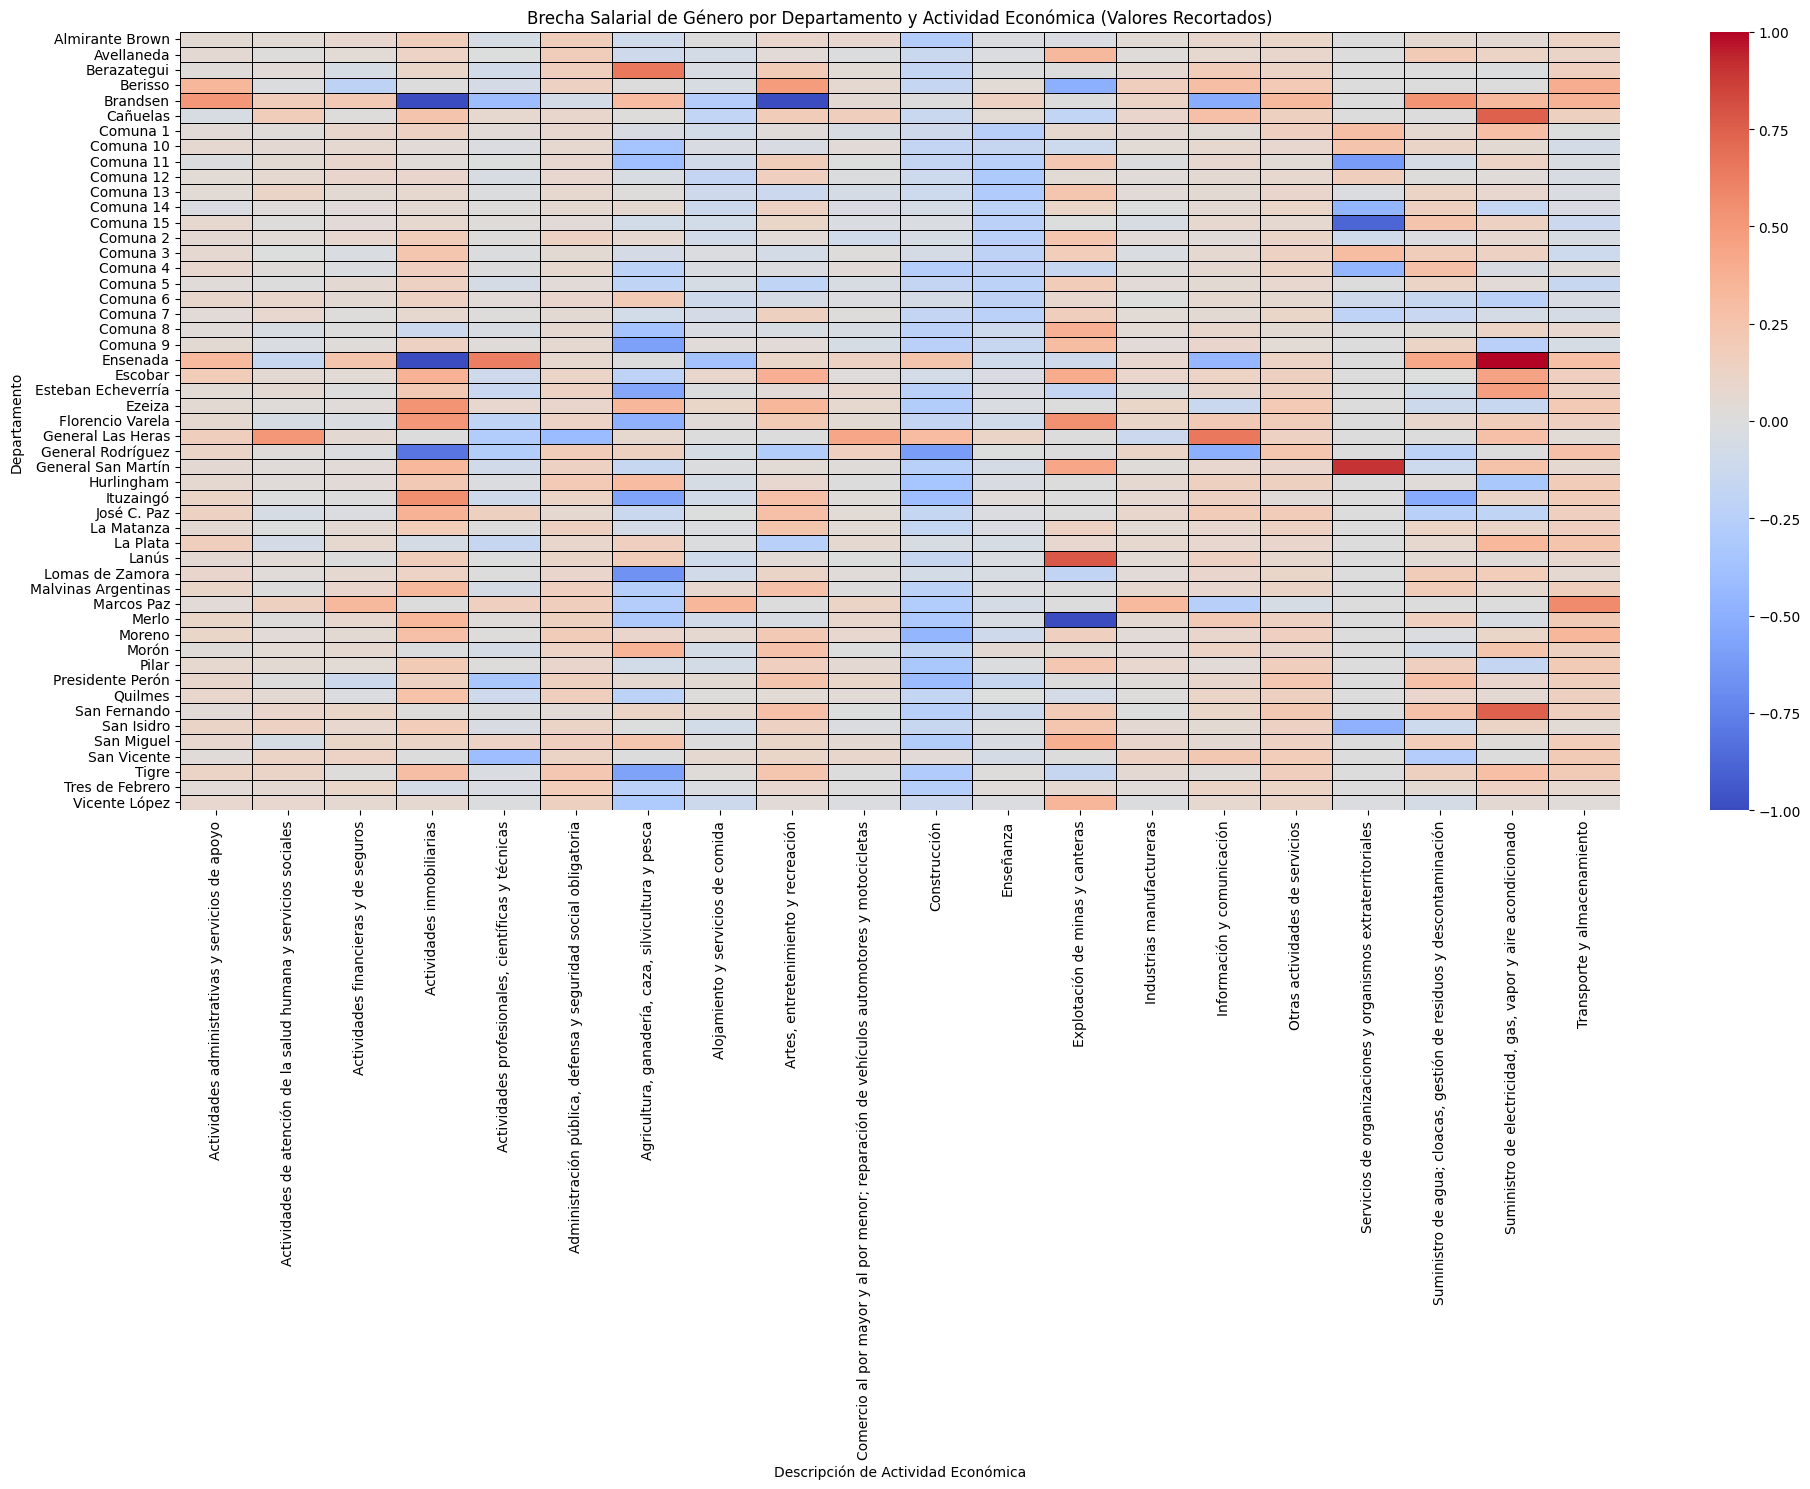

In [ ]:
# Para el análisis de la brecha salarial en el heatmap, se recortarán los valores extremos.
# Un rango de [-1, 1] asegura que la brecha se interprete como un porcentaje entre -100% y 100%.
# Se crea una copia para evitar SettingWithCopyWarning y asegurar que el clipping no afecte el DataFrame original si no se desea.
temp_df_for_heatmap = DF_Con_brecha.copy()
temp_df_for_heatmap['Brecha_Salarial_Genero_Clipped'] = temp_df_for_heatmap['Brecha_Salarial_Genero'].clip(lower=-1, upper=1)

# Agrupar por departamento y descripción de actividad económica, y calcular la media de la brecha salarial (recortada)
brecha_por_departamento_rubro_clipped = temp_df_for_heatmap.groupby(['departamento', 'clae2_description'])['Brecha_Salarial_Genero_Clipped'].mean().reset_index()

# Pivotear la tabla para el heatmap
# Rellenar NaN con la mediana de la brecha salarial recortada para evitar valores cero que puedan ser engañosos
# Si hay NaNs después del clipping y agrupación, se pueden rellenar para la visualización.
# Sin embargo, si un departamento/rubro no tiene datos, un NaN puede ser más informativo.
# Para este caso, vamos a rellenar con 0 para mantener la coherencia con el ejemplo anterior,
# pero el clipping ya maneja los valores extremos.
heatmap_data_clipped = brecha_por_departamento_rubro_clipped.pivot_table(
    index='departamento',
    columns='clae2_description',
    values='Brecha_Salarial_Genero_Clipped'
).fillna(0) # Se rellena con 0 si, por alguna razón, después del clipping y la agrupación aún hay NaNs

# Crear el heatmap con los datos recortados
plt.figure(figsize=(20, 15)) # Ajustar el tamaño para mejor visualización
sns.heatmap(
    heatmap_data_clipped,
    cmap='coolwarm', # Elegir un colormap divergente para mostrar brechas positivas y negativas
    annot=False,    # No mostrar los valores numéricos en cada celda para evitar saturación
    fmt=".2f",      # Formato de los números si annot fuera True
    linewidths=.5,  # Líneas entre celdas
    linecolor='black' # Color de las líneas entre celdas
)
plt.title('Brecha Salarial de Género por Departamento y Actividad Económica (Valores Recortados)')
plt.xlabel('Descripción de Actividad Económica')
plt.ylabel('Departamento')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Brecha Salarial de Género Promedio por Departamento y Actividad Económica

Aquí se muestra la tabla con la brecha salarial de género promedio para cada combinación de departamento y actividad económica. Para una mejor interpretabilidad, los valores de la brecha salarial se han recortado entre -1 y 1 (o -100% y 100%), donde un valor positivo indica una brecha a favor de los hombres y un valor negativo a favor de las mujeres.

In [ ]:
# Crear una versión 'recortada' de la brecha salarial en DF_Con_brecha
DF_Con_brecha['Brecha_Salarial_Genero_Clipped'] = DF_Con_brecha['Brecha_Salarial_Genero'].clip(lower=-1, upper=1)

# Agrupar por departamento y descripción de actividad económica, y calcular la media de la brecha salarial recortada
brecha_promedio_departamento_rubro = DF_Con_brecha.groupby(['departamento', 'clae2_description'])['Brecha_Salarial_Genero_Clipped'].mean().reset_index()

# Renombrar la columna para mayor claridad
brecha_promedio_departamento_rubro.rename(columns={'Brecha_Salarial_Genero_Clipped': 'Brecha_Salarial_Promedio_Recortada'}, inplace=True)

print("\n--- Brecha Salarial de Género Promedio por Departamento y Actividad Económica ---")
display(brecha_promedio_departamento_rubro.sort_values(by=['departamento', 'Brecha_Salarial_Promedio_Recortada'], ascending=[True, False]).style.format({
    'Brecha_Salarial_Promedio_Recortada': '{:.2f}'
}))


--- Brecha Salarial de Género Promedio por Departamento y Actividad Económica ---


/tmp/ipykernel_6309/1364202302.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  DF_Con_brecha['Brecha_Salarial_Genero_Clipped'] = DF_Con_brecha['Brecha_Salarial_Genero'].clip(lower=-1, upper=1)


,departamento,clae2_description,Brecha_Salarial_Promedio_Recortada
3,Almirante Brown,Actividades inmobiliarias,0.18
5,Almirante Brown,"Administración pública, defensa y seguridad social obligatoria",0.17
18,Almirante Brown,Transporte y almacenamiento,0.13
15,Almirante Brown,Otras actividades de servicios,0.11
8,Almirante Brown,"Artes, entretenimiento y recreación",0.10
14,Almirante Brown,Información y comunicación,0.09
9,Almirante Brown,Comercio al por mayor y al por menor; reparación de vehículos automotores y motocicletas,0.08
2,Almirante Brown,Actividades financieras y de seguros,0.08
16,Almirante Brown,"Suministro de agua; cloacas, gestión de residuos y descontaminación",0.07
17,Almirante Brown,"Suministro de electricidad, gas, vapor y aire acondicionado",0.06


In [ ]:
DF_Con_brecha['Brecha_Salarial_Genero'].describe().round(2)

,Brecha_Salarial_Genero
count,185713.00
mean,-6149.40
std,294537.45
min,-44284530.00
25%,-0.24
50%,0.12
75%,0.41
max,1.00


Podemos observar que como valor min hay un outlier, y eso puedo alterar los resultados de formas significativa.
se aplico este criterio para el heatmpap, pero especificamente a la columna de origen.

Entonces, ***Vamos a Hacerlo!!***

In [ ]:
DF_Con_brecha = DF_Con_brecha.copy()

Creamos una copia para evitar los warnings

In [ ]:
DF_Con_brecha['Brecha_Salarial_Genero'] = (
    DF_Con_brecha['Brecha_Salarial_Genero']
    .clip(-1, 1)
)

Con este Codigo aplicamos restricciones de maximos valores de ***-1 a 1***

In [ ]:
DF_Con_brecha['Brecha_Salarial_Genero'].describe().round(2)

,Brecha_Salarial_Genero
count,185713.00
mean,0.04
std,0.52
min,-1.00
25%,-0.24
50%,0.12
75%,0.41
max,1.00


FInalmente conseguimos que la inexistencia de ***outliers!***.

 Para la columna de ***Brecha_Salarial_Genero***

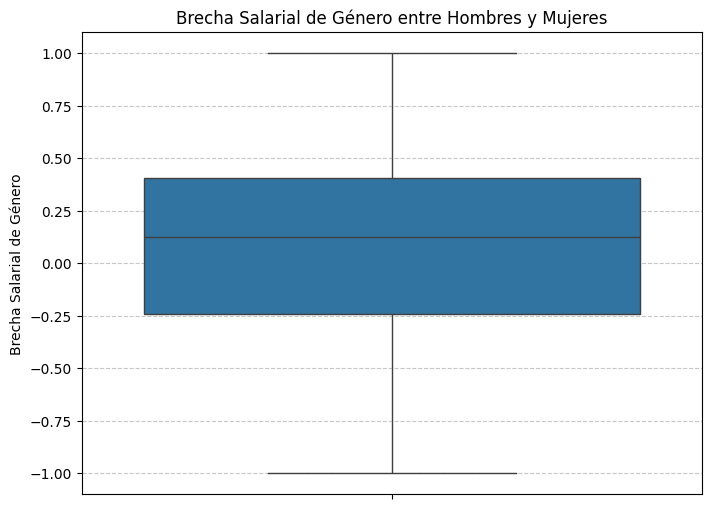

In [ ]:
#creamos un boxplot para ver los outliers y la mediana entre los quartiles
plt.figure(figsize=(8, 6))
sns.boxplot(y=DF_Con_brecha['Brecha_Salarial_Genero'])
plt.title('Brecha Salarial de Género entre Hombres y Mujeres')
plt.ylabel('Brecha Salarial de Género')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Se puede ver que existe una mediana positiva entre 0 y 0.25, lo cual muestra que se tiende a tener una brecha salaria con los hombres como mayores garantes


In [ ]:
groupby_brecha_salarial = (
  DF_Con_brecha.groupby(['departamento_id', 'departamento'])['Brecha_Salarial_Genero']
    .mean()
    .reset_index()
)

groupby_brecha_salarial.columns = ['Departamento ID', 'Departamento', 'Brecha Salarial Promedio']

# Combinar con la tabla groupby_rubros existente
Prom_Brecha_salarial = pd.merge(groupby_rubros, groupby_brecha_salarial[['Departamento ID', 'Brecha Salarial Promedio']], on='Departamento ID', how='left')

correlacion_Rubros_y_BSP = Prom_Brecha_salarial['Cantidad de Rubros'].corr(Prom_Brecha_salarial['Brecha Salarial Promedio'])

print(f"Correlación entre Cantidad de Rubros y Brecha Salarial Promedio: { correlacion_Rubros_y_BSP:.2f}")

Correlación entre Cantidad de Rubros y Brecha Salarial Promedio: -0.55


La correlación entre la cantidad de rubros y la brecha salarial promedio por departamento es de ***-0.55***. Esto indica una correlación negativa moderada, lo que sugiere que a medida que aumenta la cantidad de rubros en un departamento, la brecha salarial de género tiende a disminuir.

In [ ]:
Prom_Brecha_salarial.head()

,Departamento ID,Departamento,Cantidad de Rubros,Brecha Salarial Promedio
0,2007,Comuna 1,21,0.021098
1,2021,Comuna 3,21,0.005320
2,2042,Comuna 6,21,0.017250
3,6028,Almirante Brown,21,0.060068
4,2077,Comuna 11,21,0.002765


## Estadísticas descriptivas de la brecha salarial por departamento

Calculamos las estadísticas descriptivas del DataFrame de brecha
salarial para entender la distribución de los valores entre
los departamentos del AMBA, identificar el rango de variación
y detectar posibles valores extremos.

In [ ]:
Prom_Brecha_salarial.describe().round(2)

,Departamento ID,Cantidad de Rubros,Brecha Salarial Promedio
count,51.00,51.00,51.00
mean,5155.53,20.18,0.05
std,2030.70,0.52,0.03
min,2007.00,19.00,-0.01
25%,2094.50,20.00,0.02
50%,6274.00,20.00,0.05
75%,6532.00,20.00,0.07
max,6861.00,21.00,0.10


In [ ]:
mayor = Prom_Brecha_salarial.loc[
    Prom_Brecha_salarial['Cantidad de Rubros'].idxmax()
]

menor = Prom_Brecha_salarial.loc[
    Prom_Brecha_salarial['Cantidad de Rubros'].idxmin()
]

## Tipo de elasticidad:

**Elasticidad** **negativa** → más diversificación asociada con menor brecha salarial.

**Elasticidad** ***positiva*** → más diversificación asociada con mayor brecha salarial.

Valor cercano a 0 → relación débil.

In [ ]:
def elasticidad_arco(x1, x2, y1, y2):
    """
    Calcula la elasticidad arco entre dos observaciones.

    x: Cantidad de Rubros
    y: Brecha Salarial Promedio
    """

    variacion_y = (y2 - y1) / ((y1 + y2) / 2)
    variacion_x = (x2 - x1) / ((x1 + x2) / 2)

    return variacion_y / variacion_x

In [ ]:
elasticidad =elasticidad_arco(
    menor['Cantidad de Rubros'],
    mayor['Cantidad de Rubros'],
    menor['Brecha Salarial Promedio'],
    mayor['Brecha Salarial Promedio']
)

print(f"Elasticidad: {elasticidad:.2f}")

Elasticidad: -13.23


La elasticidad arco calculada entre la cantidad de rubros y la brecha salarial resultó negativa ***(-13,23)***, indicando una relación inversa entre ambas variables. Es decir, los departamentos con una estructura económica más diversificada tienden a presentar menores niveles de desigualdad salarial de género. No obstante, el valor obtenido debe interpretarse con cautela debido a la sensibilidad de la elasticidad frente a pequeñas variaciones en la cantidad de rubros entre departamentos.

In [ ]:
DF_educacion = pd.read_csv("https://raw.githubusercontent.com/tost1n/Tp-laboratorio/refs/heads/main/Datasets%20de%20limpieza/educacion_final.csv")

In [ ]:
DF_educacion.head(58)

,CODDPTO,DPTO_1,p_total,p_18a,pct_universitarios,pct_solosecundaria,pct_baja_educacion
0,2007,Comuna 1,221001,179737,22.130669,44.474427,25.524516
1,2014,Comuna 2,160609,138668,39.363804,42.067384,9.840050
2,2021,Comuna 3,193537,160492,19.641477,47.217307,23.745109
3,2028,Comuna 4,227024,175092,11.585338,43.353209,37.065657
4,2035,Comuna 5,192449,161535,24.823722,45.254589,19.145077
5,2042,Comuna 6,201764,168561,30.937761,42.547802,15.104324
6,2049,Comuna 7,213262,172542,20.199140,44.950215,24.232361
7,2056,Comuna 8,203888,148624,5.088007,40.765960,48.260712
8,2063,Comuna 9,167908,133580,12.465189,45.811499,31.784698
9,2070,Comuna 10,171896,140187,17.757709,46.562092,23.868832


Importamos la tabla que se realizo la limpieza de datos (fijarse en la carpeta da datos de limpieza)

In [ ]:
DF_Clave = DF_Clave.merge(
    DF_educacion,
    left_on='departamento_id',
    right_on='CODDPTO',
    how='left'
)

In [ ]:
DF_Clave.drop(columns=['CODDPTO'], inplace=True)


se elimino la columna de ***CODDPTO*** porque ya esta ***departamento_id***

In [ ]:
 # Verificamos cómo quedó el DataFrame después de incorporar los datos de educación

DF_Clave.head()

,departamento_id,departamento,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Brecha_Salarial_Genero,clae2,clae2_description,DPTO_1,p_total,p_18a,pct_universitarios,pct_solosecundaria,pct_baja_educacion
0,2007,Comuna 1,2,2.0,0.0,150000.0000,150000.000,0.00,150000.00,150000.000,0.00,1.000000,1.0,"Agricultura, ganadería, caza, silvicultura y p...",Comuna 1,221001,179737,22.130669,44.474427,25.524516
1,2007,Comuna 1,1,1.0,0.0,337377.8100,337377.810,0.00,337377.81,337377.810,0.00,1.000000,6.0,Explotación de minas y canteras,Comuna 1,221001,179737,22.130669,44.474427,25.524516
2,2007,Comuna 1,4,2.0,2.0,53289.2875,43690.815,62887.76,48271.49,43690.815,62887.76,-0.439382,10.0,Industrias manufactureras,Comuna 1,221001,179737,22.130669,44.474427,25.524516
3,2007,Comuna 1,1,0.0,1.0,72176.2000,0.000,72176.20,72176.20,0.000,72176.20,NaN,13.0,Industrias manufactureras,Comuna 1,221001,179737,22.130669,44.474427,25.524516
4,2007,Comuna 1,1,1.0,0.0,373915.9500,373915.950,0.00,373915.95,373915.950,0.00,1.000000,21.0,Industrias manufactureras,Comuna 1,221001,179737,22.130669,44.474427,25.524516


In [ ]:
DF_Clave.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508921 entries, 0 to 508920
Data columns (total 20 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   departamento_id                508921 non-null  int64  
 1   departamento                   508921 non-null  object 
 2   Cantidad_trabajadores          508921 non-null  int64  
 3   Cantidad_trabajadores_Hombres  508921 non-null  float64
 4   Cantidad_trabajadores_Mujeres  508921 non-null  float64
 5   Remuneracion_media             508921 non-null  float64
 6   Remuneracion_media_Hombres     508921 non-null  float64
 7   Remuneracion_media_Mujeres     508921 non-null  float64
 8   Remuneracion_mediana           508921 non-null  float64
 9   Remuneracion_mediana_Hombres   508921 non-null  float64
 10  Remuneracion_mediana_Mujeres   508921 non-null  float64
 11  Brecha_Salarial_Genero         419161 non-null  float64
 12  clae2                         

## Incorporación de datos educativos al DataFrame de brecha salarial

Incorporamos los datos de nivel educativo al DataFrame de brecha
salarial mediante un merge por departamento. Luego eliminamos
la columna CODDPTO que queda duplicada tras la unión, y
verificamos el resultado final con .head().

In [ ]:
DF_Con_brecha = DF_Con_brecha.merge(
    DF_educacion,
    left_on='departamento_id',
    right_on='CODDPTO',
    how='left'
)

In [ ]:
DF_Con_brecha.drop(columns=['CODDPTO'], inplace=True)

In [ ]:
DF_Con_brecha.head()

,departamento_id,departamento,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,...,Brecha_Salarial_Genero,clae2,clae2_description,Brecha_Salarial_Genero_Clipped,DPTO_1,p_total,p_18a,pct_universitarios,pct_solosecundaria,pct_baja_educacion
0,2007,Comuna 1,4,2.0,2.0,53289.287500,43690.815000,62887.760000,48271.490,43690.815,...,-0.439382,10.0,Industrias manufactureras,-0.439382,Comuna 1,221001,179737,22.130669,44.474427,25.524516
1,2007,Comuna 1,4,2.0,2.0,190019.077500,273264.705000,106773.450000,165963.885,273264.705,...,0.609267,42.0,Construcción,0.609267,Comuna 1,221001,179737,22.130669,44.474427,25.524516
2,2007,Comuna 1,17,11.0,6.0,61061.607647,72858.306364,39434.326667,58596.490,77724.220,...,0.520258,47.0,Comercio al por mayor y al por menor; reparaci...,0.520258,Comuna 1,221001,179737,22.130669,44.474427,25.524516
3,2007,Comuna 1,4,3.0,1.0,91028.990000,90027.393333,94033.780000,112981.865,131929.950,...,0.287245,49.0,Transporte y almacenamiento,0.287245,Comuna 1,221001,179737,22.130669,44.474427,25.524516
4,2007,Comuna 1,5,4.0,1.0,228995.350000,262164.687500,96318.000000,96318.000,90092.960,...,-0.069096,52.0,Transporte y almacenamiento,-0.069096,Comuna 1,221001,179737,22.130669,44.474427,25.524516


## Análisis de la relación entre nivel educativo y variables laborales

Exploramos si existe relación entre el porcentaje de población
universitaria de un departamento y su remuneración media y
sector económico. Para esto calculamos correlaciones entre
el nivel educativo, los salarios y la brecha salarial de género.

In [ ]:
DF_Clave.head().round(2)

,departamento_id,departamento,Cantidad_trabajadores,Cantidad_trabajadores_Hombres,Cantidad_trabajadores_Mujeres,Remuneracion_media,Remuneracion_media_Hombres,Remuneracion_media_Mujeres,Remuneracion_mediana,Remuneracion_mediana_Hombres,Remuneracion_mediana_Mujeres,Brecha_Salarial_Genero,clae2,clae2_description,DPTO_1,p_total,p_18a,pct_universitarios,pct_solosecundaria,pct_baja_educacion
0,2007,Comuna 1,2,2.0,0.0,150000.00,150000.00,0.00,150000.00,150000.00,0.00,1.00,1.0,"Agricultura, ganadería, caza, silvicultura y p...",Comuna 1,221001,179737,22.13,44.47,25.52
1,2007,Comuna 1,1,1.0,0.0,337377.81,337377.81,0.00,337377.81,337377.81,0.00,1.00,6.0,Explotación de minas y canteras,Comuna 1,221001,179737,22.13,44.47,25.52
2,2007,Comuna 1,4,2.0,2.0,53289.29,43690.82,62887.76,48271.49,43690.82,62887.76,-0.44,10.0,Industrias manufactureras,Comuna 1,221001,179737,22.13,44.47,25.52
3,2007,Comuna 1,1,0.0,1.0,72176.20,0.00,72176.20,72176.20,0.00,72176.20,NaN,13.0,Industrias manufactureras,Comuna 1,221001,179737,22.13,44.47,25.52
4,2007,Comuna 1,1,1.0,0.0,373915.95,373915.95,0.00,373915.95,373915.95,0.00,1.00,21.0,Industrias manufactureras,Comuna 1,221001,179737,22.13,44.47,25.52


In [ ]:
DF_Clave[['pct_universitarios',
          'Remuneracion_media']].corr().round(3)

,pct_universitarios,Remuneracion_media
pct_universitarios,1.000,0.088
Remuneracion_media,0.088,1.000


“Se observa una correlación positiva muy débil entre el porcentaje de población universitaria y la remuneración media ***(r ≈ 0.09)***, lo que sugiere que la relación entre ambas variables no es lineal ni determinante a nivel agregado.

In [ ]:
DF_Clave[['pct_universitarios',
          'clae2']].corr().round(3)

,pct_universitarios,clae2
pct_universitarios,1.000,0.044
clae2,0.044,1.000


“La correlación entre el nivel educativo y el código de actividad económica es prácticamente nula ***(r ≈ 0.04)***, lo cual es esperable dado que CLAE2 es una variable categórica

In [ ]:
Prom_universitarios =DF_Clave.groupby('clae2_description')['pct_universitarios'] \
.mean() \
.sort_values(ascending=False) \
.head(10)

In [ ]:
Prom_universitarios.head(100)

,pct_universitarios
clae2_description,
Servicios de hogares privados como empleadores,24.501122
Servicios de organizaciones y organismos extraterritoriales,24.124855
Explotación de minas y canteras,19.333643
"Actividades profesionales, científicas y técnicas",16.605291
Información y comunicación,16.276576
"Agricultura, ganadería, caza, silvicultura y pesca",16.009346
Actividades inmobiliarias,15.662169
Actividades financieras y de seguros,14.838511
"Artes, entretenimiento y recreación",14.133918


Nos muestra el porcentaje promedio de universitarios por sector

In [ ]:
Tabla_BS=DF_Con_brecha[['pct_universitarios',
               'Brecha_Salarial_Genero']]

Tabla_BS.head()

,pct_universitarios,Brecha_Salarial_Genero
0,22.130669,-0.439382
1,22.130669,0.609267
2,22.130669,0.520258
3,22.130669,0.287245
4,22.130669,-0.069096


In [ ]:
DF_Con_brecha[['pct_universitarios',
               'Brecha_Salarial_Genero']].corr().round(3)

,pct_universitarios,Brecha_Salarial_Genero
pct_universitarios,1.000,-0.037
Brecha_Salarial_Genero,-0.037,1.000


Se observa una correlación prácticamente nula ***(r ≈ -0.04)*** entre el porcentaje de población universitaria y la brecha salarial de género, lo que indica que no existe una relación lineal significativa entre ambas variables a nivel agregado

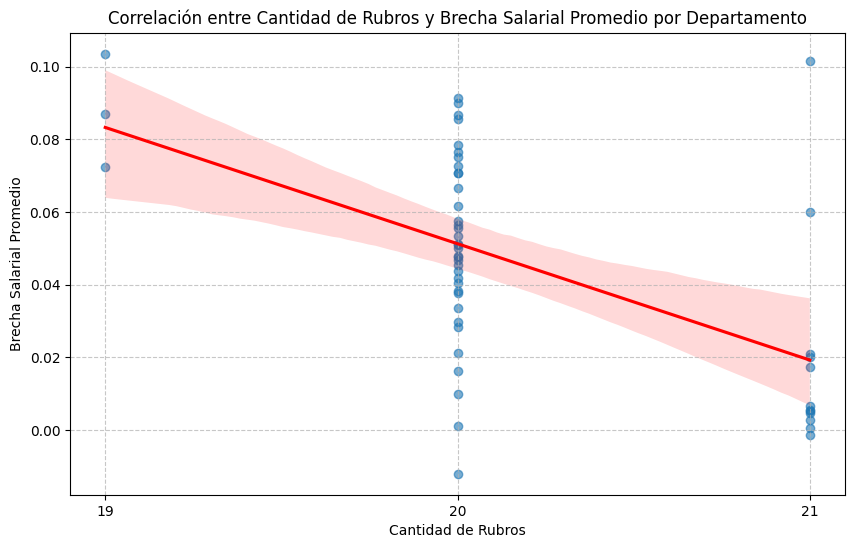

In [ ]:
import matplotlib.ticker as ticker

plt.figure(figsize=(10, 6))
sns.regplot(x='Cantidad de Rubros', y='Brecha Salarial Promedio', data=Prom_Brecha_salarial, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlación entre Cantidad de Rubros y Brecha Salarial Promedio por Departamento')
plt.xlabel('Cantidad de Rubros')
plt.ylabel('Brecha Salarial Promedio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) # Ensure x-axis ticks are integers
plt.show()

Este gráfico muestra la relación entre la cantidad de rubros económicos de un departamento y su brecha salarial promedio. La línea roja de tendencia sugiere que, a mayor diversidad de rubros económicos (más 'Cantidad de Rubros'), la brecha salarial de género tiende a ser menor. La correlación negativa de -0.55 lo confirma: más diversidad económica se asocia con menos desigualdad salarial.

# Remuneración media por departamento

Para analizar los patrones salariales del AMBA, agrupamos los datos
por departamento y calculamos la remuneración media de cada uno.
Este estadístico nos permite identificar qué zonas del área
metropolitana concentran los salarios más altos y cuáles los más bajos,
siendo un insumo clave para responder si los departamentos con mayor
diversidad económica tienden a pagar mejores salarios.

In [ ]:
groupby_salario = (
    DF_Clave.groupby('departamento_id')['Remuneracion_media']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
groupby_salario.columns = ['Departamento', 'Remuneración Media ($)']
groupby_salario['Remuneración Media ($)'] = groupby_salario['Remuneración Media ($)'].round(2)

display(groupby_salario.head(10).style
    .format({'Remuneración Media ($)': '${:,.2f}'})
    .background_gradient(subset=['Remuneración Media ($)'], cmap='Greens')
    .set_properties(**{'text-align': 'center'})
)

,Departamento,Remuneración Media ($)
0,2014,"$225,397.30"
1,2098,"$224,149.60"
2,2091,"$215,694.90"
3,2007,"$189,571.38"
4,6756,"$178,264.60"
5,6861,"$177,206.50"
6,2084,"$175,607.19"
7,2042,"$174,563.46"
8,2077,"$157,386.49"
9,2105,"$150,345.86"


# — Total de trabajadores por departamento

Calculamos cuántos trabajadores registrados tiene cada departamento
del AMBA. Este estadístico permite entender el tamaño del mercado
laboral de cada zona y contextualizar los promedios salariales:
un salario alto en un departamento pequeño tiene menos peso
que en uno con mucha población empleada.

In [ ]:
groupby_trabajadores = (
    DF_Clave.groupby('departamento_id')['Cantidad_trabajadores']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
groupby_trabajadores.columns = ['Departamento', 'Total Trabajadores']

display(groupby_trabajadores.head(10).style
    .format({'Total Trabajadores': '{:,.0f}'})
    .background_gradient(subset=['Total Trabajadores'], cmap='Blues')      #mientras mas azul oscuro es el numero, mas trabajadores tiene
    .set_properties(**{'text-align': 'center'})
)

,Departamento,Total Trabajadores
0,6427,"186,525"
1,2091,"82,094"
2,6028,"81,589"
3,2098,"78,870"
4,6490,"74,573"
5,6658,"71,559"
6,6441,"66,928"
7,2084,"66,915"
8,2021,"65,195"
9,2105,"60,605"


Correlación entre Total de Trabajadores y Brecha Salarial Promedio: -0.46


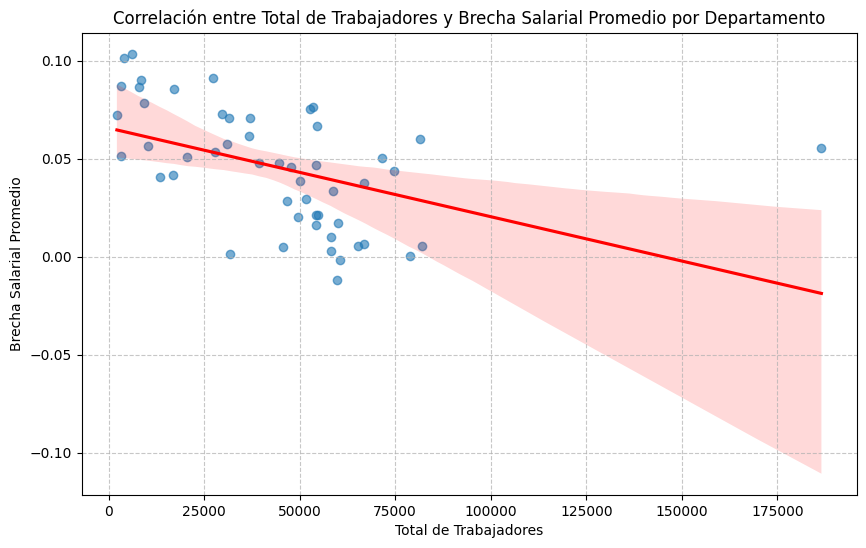

In [ ]:
groupby_trabajadores_renamed = groupby_trabajadores.rename(columns={'Departamento': 'Departamento ID'})
analisis_final = pd.merge(Prom_Brecha_salarial, groupby_trabajadores_renamed, on='Departamento ID')

correlacion_trabajadores_y_BSP = analisis_final['Total Trabajadores'].corr(analisis_final['Brecha Salarial Promedio'])

print(f"Correlación entre Total de Trabajadores y Brecha Salarial Promedio: {correlacion_trabajadores_y_BSP:.2f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='Total Trabajadores', y='Brecha Salarial Promedio', data=analisis_final, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlación entre Total de Trabajadores y Brecha Salarial Promedio por Departamento')
plt.xlabel('Total de Trabajadores')
plt.ylabel('Brecha Salarial Promedio')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


**--- Analisis de la Correlacion ---**

La correlación entre la cantidad total de trabajadores y la brecha salarial promedio por departamento es de -0.46.
Esto sugiere una relación negativa moderada: a mayor número de trabajadores, tiende a haber una brecha salarial más pequeña o incluso a favor de las mujeres.

### Distribución de la Brecha Salarial de Género

Este histograma muestra la frecuencia de los valores de la `Brecha_Salarial_Genero` después de haber sido recortados entre -1 y 1. Un valor de 0 indica paridad, valores positivos indican que los hombres ganan más, y valores negativos indican que las mujeres ganan más.

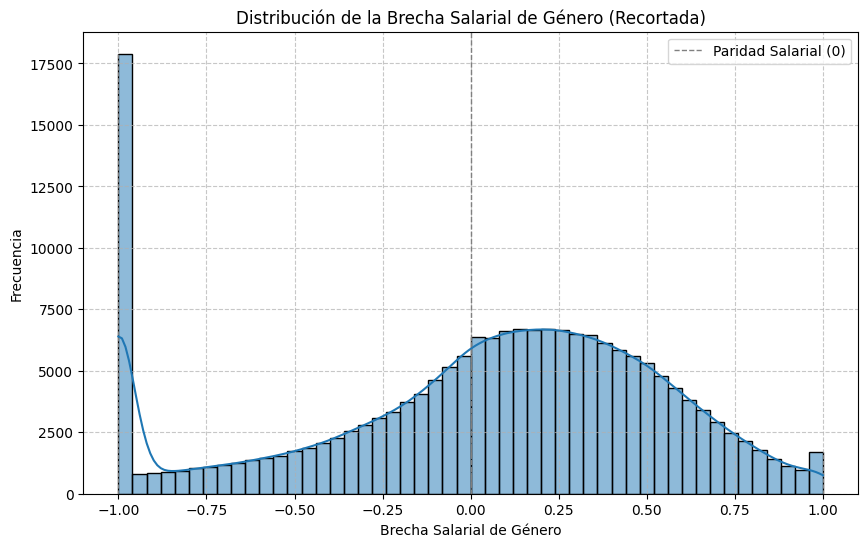

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(DF_Con_brecha['Brecha_Salarial_Genero'], bins=50, kde=True)
plt.title('Distribución de la Brecha Salarial de Género (Recortada)')
plt.xlabel('Brecha Salarial de Género')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, label='Paridad Salarial (0)')
plt.legend()
plt.show()

### Correlación entre Cantidad de Rubros y Remuneración Media

Para responder si los departamentos con una estructura económica más diversificada presentan salarios más altos, primero calcularemos la correlación entre la 'Cantidad de Rubros' y la 'Remuneración Media ($)'. Luego, visualizaremos esta relación con un diagrama de dispersión.

Correlación entre Cantidad de Rubros y Remuneración Media: 0.48


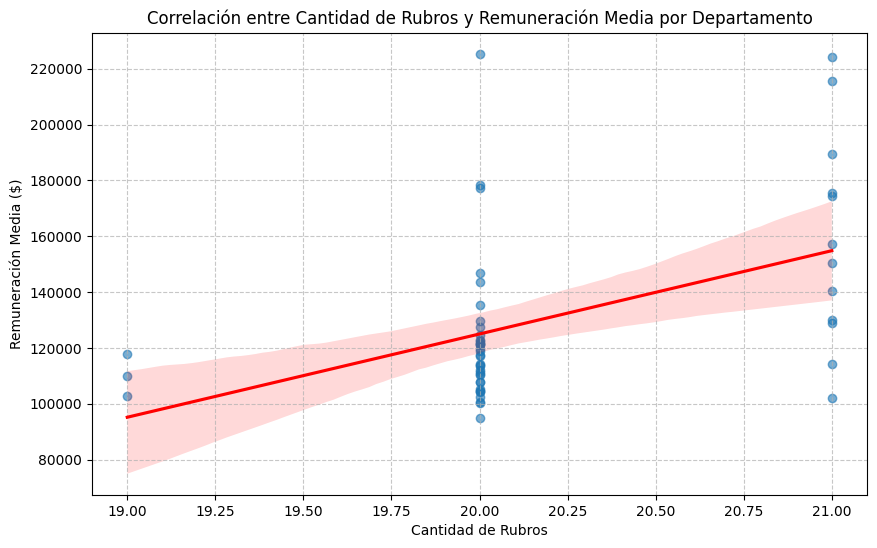

In [ ]:
merged_rubros_salario = pd.merge(groupby_rubros, groupby_salario.rename(columns={'Departamento': 'Departamento ID'}), on='Departamento ID', how='left')

correlacion_rubros_salario = merged_rubros_salario['Cantidad de Rubros'].corr(merged_rubros_salario['Remuneración Media ($)'])

print(f"Correlación entre Cantidad de Rubros y Remuneración Media: {correlacion_rubros_salario:.2f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='Cantidad de Rubros', y='Remuneración Media ($)', data=merged_rubros_salario, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Correlación entre Cantidad de Rubros y Remuneración Media por Departamento')
plt.xlabel('Cantidad de Rubros')
plt.ylabel('Remuneración Media ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



La correlación entre la cantidad de rubros y la remuneración media por departamento es de 0.48.
Esto sugiere una relación positiva moderada: a mayor número de rubros, tiende a haber salarios medios más altos.

In [ ]:
#mapa creado con ayuda de Gemini (no todo)
import folium
import requests
import json

comunas_geojson_url_raw = "https://raw.githubusercontent.com/tost1n/Tp-laboratorio/main/comunas.geojson"
partidos_geojson_url_url_raw = "https://raw.githubusercontent.com/tost1n/Tp-laboratorio/main/partidos.geojson"

# Obtener datos GeoJSON
try:
    response_comunas = requests.get(comunas_geojson_url_raw)
    response_comunas.raise_for_status() # Lanza un HTTPError para respuestas incorrectas (4xx o 5xx)
    comunas_geojson = response_comunas.json()

    response_partidos = requests.get(partidos_geojson_url_url_raw)
    response_partidos.raise_for_status() # Lanza un HTTPError para respuestas incorrectas (4xx o 5xx)
    partidos_geojson = response_partidos.json()
except requests.exceptions.RequestException as e:
    print(f"Error al obtener archivos GeoJSON: {e}")
    raise

# Combinar ambas FeatureCollections GeoJSON en una sola
combined_geojson = {
    "type": "FeatureCollection",
    "features": comunas_geojson['features'] + partidos_geojson['features']
}

# Crear mapeos desde df_jurisdicciones para estandarizar los IDs de departamento
# CABA: mapear el número de comuna (desde geojson) al departamento_id (desde df_jurisdicciones)
caba_dept_map_df = df_jurisdicciones[df_jurisdicciones['provincia'] == 'CABA']
caba_comuna_to_departamento_id = {
    int(row['departamento'].split(' ')[1]): row['departamento_id']
    for index, row in caba_dept_map_df.iterrows()
}

# PBA: mapear el nombre del departamento (desde geojson) al departamento_id (desde df_jurisdicciones)
pba_dept_map_df = df_jurisdicciones[df_jurisdicciones['provincia'] == 'PBA']
pba_departamento_name_to_departamento_id = {
    row['departamento']: row['departamento_id']
    for index, row in pba_dept_map_df.iterrows()
}

# Crear un mapeo inverso para el ID de departamento a nombre de departamento para tooltips
dept_id_to_name_map = df_jurisdicciones.set_index('departamento_id')['departamento'].to_dict()

# Depuración: Recopilar valores 'nam' de PBA no mapeados y listar nombres de PBA esperados
unmapped_pba_names = []

# Añadir una propiedad consistente 'departamento_id_map' y 'departamento_name_map' a cada característica GeoJSON
for feature in combined_geojson['features']:
    mapped_id = None
    if feature['properties'].get('objeto') == 'BARRIO': # Característica de comunas.geojson (CABA)
        comuna_num = feature['properties'].get('comuna')
        if comuna_num in caba_comuna_to_departamento_id:
            mapped_id = caba_comuna_to_departamento_id[comuna_num]
    elif feature['properties'].get('gna') == 'Partido': # Corregido: Característica de partidos.geojson (PBA), verificar propiedad 'gna'
        partido_name = feature['properties'].get('nam') # Corregido de 'nombre' a 'nam'
        if partido_name and partido_name not in pba_departamento_name_to_departamento_id:
            unmapped_pba_names.append(partido_name)
        if partido_name in pba_departamento_name_to_departamento_id:
            mapped_id = pba_departamento_name_to_departamento_id[partido_name]

    feature['properties']['departamento_id_map'] = mapped_id
    if mapped_id is not None and mapped_id in dept_id_to_name_map:
        feature['properties']['departamento_name_map'] = dept_id_to_name_map[mapped_id]
    else:
        feature['properties']['departamento_name_map'] = "Desconocido"

# Filtrar las características que no tienen un ID mapeado válido
filtered_geojson_features = [f for f in combined_geojson['features'] if f['properties'].get('departamento_id_map') is not None]
combined_geojson_filtered = {"type": "FeatureCollection", "features": filtered_geojson_features}

# --- Preparar todos los datos de salario y brecha ---
# 1. Salario Medio Total (ya hecho en groupby_salario)
salary_data_for_map = groupby_salario.copy()
salary_data_for_map.rename(columns={'Departamento': 'departamento_id'}, inplace=True)
salary_data_for_map['departamento_id'] = salary_data_for_map['departamento_id'].astype(str)
salary_dict = salary_data_for_map.set_index('departamento_id')['Remuneración Media ($)'].to_dict()

# 2. Salario Medio Mujeres
groupby_salario_mujeres = (
    DF_limpio.groupby('departamento_id')['Remuneracion_media_Mujeres']
    .mean()
    .reset_index()
)
groupby_salario_mujeres.columns = ['departamento_id', 'Remuneración Media Mujeres ($)']
groupby_salario_mujeres['Remuneración Media Mujeres ($)'] = groupby_salario_mujeres['Remuneración Media Mujeres ($)'].round(2)
groupby_salario_mujeres['departamento_id'] = groupby_salario_mujeres['departamento_id'].astype(str)
salary_mujeres_dict = groupby_salario_mujeres.set_index('departamento_id')['Remuneración Media Mujeres ($)'].to_dict()

# 3. Brecha Salarial de Género (Brecha Salarial Promedio)
groupby_brecha_salarial_departamento = (
    DF_Con_brecha.groupby('departamento_id')['Brecha_Salarial_Genero']
    .mean()
    .reset_index()
)
groupby_brecha_salarial_departamento.columns = ['departamento_id', 'Brecha Salarial Promedio']
groupby_brecha_salarial_departamento['Brecha Salarial Promedio'] = groupby_brecha_salarial_departamento['Brecha Salarial Promedio'].round(4)
groupby_brecha_salarial_departamento['departamento_id'] = groupby_brecha_salarial_departamento['departamento_id'].astype(str)
brecha_dict = groupby_brecha_salarial_departamento.set_index('departamento_id')['Brecha Salarial Promedio'].to_dict()


# Añadir toda la información de salario y brecha a las propiedades GeoJSON para mostrar en tooltips y popups
for feature in combined_geojson_filtered['features']:
    dept_id_mapped = str(feature['properties']['departamento_id_map'])

    # Salario Medio Total
    if dept_id_mapped in salary_dict:
        feature['properties']['Salario_Medio_Total'] = f"{salary_dict[dept_id_mapped]:,.2f}"
    else:
        feature['properties']['Salario_Medio_Total'] = "Datos no disponibles"

    # Salario Medio Mujeres
    if dept_id_mapped in salary_mujeres_dict:
        feature['properties']['Salario_Medio_Mujeres'] = f"{salary_mujeres_dict[dept_id_mapped]:,.2f}"
    else:
        feature['properties']['Salario_Medio_Mujeres'] = "Datos no disponibles"

    # Brecha Salarial de Género
    if dept_id_mapped in brecha_dict:
        feature['properties']['Brecha_Salarial_Genero_Promedio'] = f"{brecha_dict[dept_id_mapped]:.2%}" # Formato como porcentaje
    else:
        feature['properties']['Brecha_Salarial_Genero_Promedio'] = "Datos no disponibles"


# Definir la ubicación predeterminada del mapa (Buenos Aires) y el nivel de zoom
map_center = [-34.6037, -58.3816] # Centro aproximado de AMBA
map_zoom = 9

# Crear el mapa de Folium
m = folium.Map(location=map_center, zoom_start=map_zoom, tiles='cartodbpositron') # Usando un conjunto de tiles más claro

# --- Añadir capas Choropleth con tooltips individuales ---

# 1. Capa de Salario Medio Total
folium.Choropleth(
    geo_data=combined_geojson_filtered,
    name='Salario Medio Total',
    data=salary_data_for_map,
    columns=['departamento_id', 'Remuneración Media ($)'],
    key_on='feature.properties.departamento_id_map',
    fill_color='YlGnBu',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Salario Medio Total por Departamento',
    highlight=True,
    line_color='black',
    tooltip=folium.features.GeoJsonTooltip(
        fields=['departamento_name_map', 'Salario_Medio_Total'],
        aliases=['Departamento:', 'Salario Medio Total:'],
        localize=True
    )
).add_to(m)

# 2. Capa de Salario Medio Mujeres
folium.Choropleth(
    geo_data=combined_geojson_filtered,
    name='Salario Medio Mujeres',
    data=groupby_salario_mujeres,
    columns=['departamento_id', 'Remuneración Media Mujeres ($)'],
    key_on='feature.properties.departamento_id_map',
    fill_color='PuRd', # Esquema de color Violeta-Rojo
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Salario Medio Mujeres por Departamento',
    highlight=True,
    line_color='black',
    tooltip=folium.features.GeoJsonTooltip(
        fields=['departamento_name_map', 'Salario_Medio_Mujeres'],
        aliases=['Departamento:', 'Salario Medio Mujeres:'],
        localize=True
    )
).add_to(m)

# 3. Capa de Brecha Salarial de Género
folium.Choropleth(
    geo_data=combined_geojson_filtered,
    name='Brecha Salarial de Género',
    data=groupby_brecha_salarial_departamento,
    columns=['departamento_id', 'Brecha Salarial Promedio'],
    key_on='feature.properties.departamento_id_map',
    fill_color='RdBu', # Esquema de color divergente Rojo-Azul para brecha positiva/negativa
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Brecha Salarial Promedio por Departamento',
    highlight=True,
    line_color='black',
    tooltip=folium.features.GeoJsonTooltip(
        fields=['departamento_name_map', 'Brecha_Salarial_Genero_Promedio'],
        aliases=['Departamento:', 'Brecha Salarial Género:'],
        localize=True
    )
).add_to(m)

# --- Añadir una capa GeoJson transparente para tooltips de hover completos ---
def style_function(feature):
    return {
        'fillOpacity': 0, # Relleno completamente transparente
        'color': 'transparent', # Borde completamente transparente
        'weight': 0 # Sin grosor de borde
    }

# Añadir un tooltip a esta capa transparente para mostrar todos los datos relevantes al pasar el ratón
folium.GeoJson(
    combined_geojson_filtered,
    style_function=style_function,
    tooltip=folium.features.GeoJsonTooltip(
        fields=['departamento_name_map', 'Salario_Medio_Total', 'Salario_Medio_Mujeres', 'Brecha_Salarial_Genero_Promedio'],
        aliases=['Departamento:', 'Salario Total:', 'Salario Mujeres:', 'Brecha Salarial:'],
        localize=True,
        sticky=False, # Hacerlo no-pegajoso para que desaparezca cuando el ratón salga
        max_width=800
    ),
    control=False # No añadir esta capa al control de capas
).add_to(m)

# Añadir Control de Capas al mapa, permitiendo a los usuarios alternar capas
folium.LayerControl().add_to(m)

# Mostrar el mapa
display(m)